In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import copy
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.feature_selection import mutual_info_regression
from lime.lime_tabular import LimeTabularExplainer

import lightgbm as lgb
import xgboost as xgb
import importlib
import bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison

for mod in (bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison):
    importlib.reload(mod)

from bootstrap import *
from distribution_estimation import *
from plotting import *
from model_wrapper import *
from performance_comparison import *
print("Modules reloaded.")

/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modules reloaded.


In [2]:
params = {
    #'booster':'gbtree',
        #'silent':0, # 1 - info output; 0 - silent
        #'scale_pos_weight': 33, # If value > 0, helps with fast convergence in case of imbalanced class samples
        'objective': 'binary:logistic', # for binary classification
        'seed':2, # random seed
        'eval_metric': 'logloss',  # binary logloss
        'eta': 0.5, # learning rate
        'max_depth': 20,
        'min_child_weight': 0.2,
        'subsample': 0.8, 
        'colsample_bytree': 0.6,
        #'gamma': 0.418,
        #'lambda': 1.814,
        #'alpha': 3.17,
       }

In [3]:
def simulate_known_importance_classification(
    n=600,          # sample size
    d=40,           # total number of features
    s=8,            # number of true signals
    sigma=1.5,      # within-group SD (moderate, not too small)
    rho=0.20,       # common correlation among features
    class_prob=0.5, # balanced classes
    max_delta=3.0,  # strongest signal separation
    min_delta=0.8,  # weakest signal separation
    seed=123
):
    """
    Simulate a two-class classification dataset with:
    - s true signal features
    - d-s noise features
    - known descending importance order among signals
    - equal within-class covariance for both groups
    """

    rng = np.random.default_rng(seed)

    if not (s < d < n):
        raise ValueError("Require s < d < n.")

    # Balanced binary response
    y = rng.binomial(1, class_prob, size=n)

    # Descending signal strengths: delta_1 > delta_2 > ... > delta_s
    deltas = np.linspace(max_delta, min_delta, s)

    # Means for the two classes
    mu1 = np.zeros(d)
    mu0 = np.zeros(d)
    mu1[:s] = deltas / 2.0
    mu0[:s] = -deltas / 2.0

    # Equal covariance for both groups
    # Exchangeable correlation structure
    R = np.full((d, d), rho)
    np.fill_diagonal(R, 1.0)
    Sigma = (sigma ** 2) * R

    # Generate X | Y
    X = np.empty((n, d))

    idx1 = np.where(y == 1)[0]
    idx0 = np.where(y == 0)[0]

    if len(idx1) > 0:
        X[idx1] = rng.multivariate_normal(mean=mu1, cov=Sigma, size=len(idx1))
    if len(idx0) > 0:
        X[idx0] = rng.multivariate_normal(mean=mu0, cov=Sigma, size=len(idx0))

    feature_names = [f"x{j+1}" for j in range(d)]
    df = pd.DataFrame(X, columns=feature_names)
    df["y"] = y

    # Ground-truth importance table
    truth = pd.DataFrame({
        "feature": feature_names,
        "is_signal": [j < s for j in range(d)],
        "delta": list(deltas) + [0.0] * (d - s),
        "true_rank": list(range(1, s + 1)) + [None] * (d - s)
    })

    return df, truth, Sigma, mu0, mu1

In [4]:
# import numpy as np
# import pandas as pd

# def simulate_zero_inflated_classification(
#     n=600,
#     d=40,
#     s=8,
#     sigma=1.5,
#     pi_zero=0.3,
#     max_delta=3.0,
#     min_delta=0.8,
#     seed=123
# ):
#     rng = np.random.default_rng(seed)

#     if not (s < d < n):
#         raise ValueError("Require s < d < n.")

#     y = rng.binomial(1, 0.5, size=n)
#     deltas = np.linspace(max_delta, min_delta, s)

#     X = np.zeros((n, d))

#     for j in range(d):
#         is_signal = j < s
#         delta_j = deltas[j] if is_signal else 0.0

#         mu1 = delta_j / 2.0
#         mu0 = -delta_j / 2.0

#         for i in range(n):
#             if rng.random() < pi_zero:
#                 X[i, j] = 0.0
#             else:
#                 mu = mu1 if y[i] == 1 else mu0
#                 X[i, j] = rng.normal(mu, sigma)

#     feature_names = [f"x{j+1}" for j in range(d)]
#     df = pd.DataFrame(X, columns=feature_names)
#     df["y"] = y

#     truth = pd.DataFrame({
#         "feature": feature_names,
#         "is_signal": [j < s for j in range(d)],
#         "delta": list(deltas) + [0.0] * (d - s),
#         "pi_zero": [pi_zero] * d,
#         "true_rank": list(range(1, s + 1)) + [None] * (d - s)
#     })

#     return df, truth

In [5]:
import numpy as np
import pandas as pd


def simulate_zero_inflated_classification(
    n=600,
    d=40,
    s=8,
    sigma_signal=1.5,        # within-class std for SIGNAL features
    sigma_noise=0.3,         # within-class std for NOISE features (smaller)
    pi_zero_signal=0.3,      # zero-inflation rate for signals
    pi_zero_noise=0.7,       # zero-inflation rate for noise (heavier)
    max_delta=3.0,
    min_delta=0.8,
    seed=123,
):
    """
    Zero-inflated Gaussian binary classification simulator with weakened noise.

    Signal features (j < s):
        X[i, j] = 0                             w.p. pi_zero_signal
                ~ N(+delta_j/2, sigma_signal^2) if y_i = 1
                ~ N(-delta_j/2, sigma_signal^2) if y_i = 0
        delta_j decreases linearly from max_delta to min_delta (known ranking).

    Noise features (j >= s):
        X[i, j] = 0                    w.p. pi_zero_noise
                ~ N(0, sigma_noise^2)  otherwise
        No class-dependent mean; smaller variance; mostly zero.
    """
    rng = np.random.default_rng(seed)

    if not s < d:
        raise ValueError("Require s < d.")
    if s >= n:
        raise ValueError("Require s < n.")

    # ---- labels ----
    y = rng.binomial(1, 0.5, size=n)

    # ---- per-feature parameters ----
    deltas_signal = np.linspace(max_delta, min_delta, s)
    deltas  = np.concatenate([deltas_signal, np.zeros(d - s)])          # (d,)
    sigmas  = np.concatenate([np.full(s, sigma_signal),
                              np.full(d - s, sigma_noise)])             # (d,)
    pi_zero = np.concatenate([np.full(s, pi_zero_signal),
                              np.full(d - s, pi_zero_noise)])           # (d,)

    # ---- per-cell means ----
    sign = np.where(y == 1, 1.0, -1.0)[:, None]                         # (n, 1)
    mu   = sign * (deltas / 2.0)[None, :]                               # (n, d)

    # ---- Gaussian draws with per-feature sigma ----
    X = rng.normal(loc=mu, scale=sigmas[None, :], size=(n, d))

    # ---- zero-inflation with per-feature rate ----
    zero_mask = rng.random(size=(n, d)) < pi_zero[None, :]
    X[zero_mask] = 0.0

    # ---- package ----
    feature_names = [f"x{j + 1}" for j in range(d)]
    df = pd.DataFrame(X, columns=feature_names)
    df["y"] = y

    truth = pd.DataFrame({
        "feature":   feature_names,
        "is_signal": [j < s for j in range(d)],
        "delta":     deltas,
        "sigma":     sigmas,
        "pi_zero":   pi_zero,
        "true_rank": list(range(1, s + 1)) + [np.nan] * (d - s),
    })

    return df, truth

In [6]:
def _clone_wrapper(wrapper, input_dim=None):
    if isinstance(wrapper, XGBoostWrapper):
        return XGBoostWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, LightGBMWrapper):
        return LightGBMWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, SklearnWrapper):
        return SklearnWrapper(
            model_class=wrapper.model_class,
            model_params=wrapper.model_params.copy(),
            use_tree_explainer=wrapper.use_tree_explainer,
            use_linear_explainer=wrapper.use_linear_explainer,
        )
    if isinstance(wrapper, CatBoostWrapper):
        return CatBoostWrapper(params=wrapper.params.copy(), num_boost_round=getattr(wrapper, 'num_boost_round', 100))
    return copy.deepcopy(wrapper)


def _predict(wrapper, X):
    if isinstance(wrapper, XGBoostWrapper):
        return wrapper.model.predict(xgb.DMatrix(X, enable_categorical=True))
    if isinstance(wrapper, LightGBMWrapper):
        return wrapper.model.predict(X)
    if isinstance(wrapper, (CatBoostWrapper, SklearnWrapper)):
        return wrapper.model.predict(X)
    raise TypeError(f'Unknown wrapper: {type(wrapper)}')


def get_shap_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
        sv = w.compute_shap(X_tr, task='regression')
    importance = np.abs(sv).sum(axis=tuple(range(sv.ndim - 1)))
    return (
        pd.DataFrame({'feature': X_tr.columns, 'importance': importance})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_gain_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    if isinstance(w, LightGBMWrapper):
        imp = w.model.feature_importance(importance_type='gain').astype(float)
    elif isinstance(w, XGBoostWrapper):
        scores = w.model.get_score(importance_type='gain')
        imp = np.array([scores.get(f, 0.0) for f in X_tr.columns], dtype=float)
    elif isinstance(w, CatBoostWrapper):
        imp = np.array(w.model.get_feature_importance(), dtype=float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'feature_importances_'):
        imp = w.model.feature_importances_.astype(float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'coef_'):
        imp = np.abs(w.model.coef_).ravel().astype(float)
    else:
        return None
    return (
        pd.DataFrame({'feature': X_tr.columns.tolist(), 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_lime_ranking(wrapper, X_tr, y_tr, n_samples=10, num_features=50):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    X_arr = X_tr.values.astype(float)
    feat_names = X_tr.columns.tolist()
    def _pred(arr, _w=w):
        return _predict(_w, pd.DataFrame(arr, columns=feat_names))
    explainer = LimeTabularExplainer(
        X_arr, feature_names=feat_names,
        mode='regression', random_state=42,
    )
    idx = np.random.RandomState(42).choice(len(X_arr), min(n_samples, len(X_arr)), replace=False)
    imp = np.zeros(len(feat_names))
    for i in idx:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            exp = explainer.explain_instance(X_arr[i], _pred, num_features=num_features)
        for fi, w_val in exp.local_exp[0]:
            imp[fi] += abs(w_val)
    imp /= len(idx)
    return (
        pd.DataFrame({'feature': feat_names, 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def evaluate_topk(wrapper, ranking_df, X_tr, X_te, y_tr, y_te, k_values=range(1, 11)):
    results = {'rmse': [], 'mae': [], 'mape': []}
    for k in k_values:
        selected = ranking_df['feature'].head(k).tolist()
        selected_set = set(selected)
        feats = [c for c in X_tr.columns if c in selected_set]

        try:
            w = _clone_wrapper(wrapper, input_dim=len(feats))
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                w.fit(X_tr[feats], y_tr)
                y_pred = _predict(w, X_te[feats])
            y_te_arr = np.asarray(y_te).ravel()
            results['rmse'].append(np.sqrt(mean_squared_error(y_te_arr, y_pred)))
            results['mae'].append(mean_absolute_error(y_te_arr, y_pred))
            results['mape'].append(np.mean(np.abs((y_te_arr - y_pred) / y_te_arr)) * 100)
        except Exception:
            for m in results:
                results[m].append(float('nan'))
    return results

In [7]:
# For UJIIndoorLoc:
# n ≈ 19,937 training samples
# p = 520 WAP features
# response = LONGITUDE or LATITUDE
# Do NOT use log-transform for y.

seed = 42
lgb_wrapper = create_model_wrapper(
    'lightgbm',
    params={
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.03,
        'max_depth': 7,
        'num_leaves': 63,
        'min_data_in_leaf': 30,
        'feature_fraction': 0.7,      # 0.7 × 520 ≈ 364 features per tree
        'bagging_fraction': 0.8,
        'bagging_freq': 1,
        'lambda_l1': 0.01,
        'lambda_l2': 1.0,
        'verbose': -1,
        'seed': seed,
        'num_threads': 4,
    },
    num_boost_round=300,
)

xgb_wrapper = create_model_wrapper(
    'xgboost',
    params={
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'eta': 0.03,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.7,      # 0.7 × 520 ≈ 364 features per tree
        'min_child_weight': 10,
        'reg_alpha': 0.01,
        'reg_lambda': 2.0,
        'tree_method': 'hist',
        'seed': seed,
        'nthread': 4,
    },
    num_boost_round=300,
)

rf_wrapper = create_model_wrapper(
    'sklearn',
    model_class=RandomForestRegressor,
    model_params={
        'n_estimators': 300,
        'random_state': seed,
        'max_depth': 15,
        'min_samples_leaf': 5,
        'max_features': 0.3,          # 0.3 × 520 ≈ 156 features per split
        'n_jobs': 4,
    },
    use_tree_explainer=True,
)

cb_wrapper = create_model_wrapper(
    'catboost',
    params={
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': seed,
        'learning_rate': 0.03,
        'depth': 6,
        'iterations': 300,
        'l2_leaf_reg': 5.0,
        'rsm': 0.7,                   # 0.7 × 520 ≈ 364 features
        'thread_count': 4,
        'verbose': False,
        'allow_writing_files': False,
    },
)

gb_wrapper = create_model_wrapper(
    'sklearn',
    model_class=GradientBoostingRegressor,
    model_params={
        'n_estimators': 150,
        'max_depth': 4,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'max_features': 0.5,          # 0.5 × 520 ≈ 260 features
        'min_samples_leaf': 10,
        'random_state': seed,
    },
    use_tree_explainer=True,
)

ridge_wrapper = create_model_wrapper(
    'sklearn',
    model_class=Ridge,
    model_params={
        'alpha': 10.0,                # stronger than 1.0, but not too large
        'random_state': seed,
    },
    use_linear_explainer=True,
    use_tree_explainer=False,
)

MODELS = {
    'LightGBM':         lgb_wrapper,
    'XGBoost':          xgb_wrapper,
    'RandomForest':     rf_wrapper,
    'CatBoost':         cb_wrapper,
    'GradientBoosting': gb_wrapper,
    'Ridge':            ridge_wrapper,
}

# Low dimension

In [43]:
# df, truth = simulate_zero_inflated_classification(
#     n=600,
#     d=40,
#     s=8,
#     sigma=3,
#     pi_zero=0.5,
#     max_delta=2.5,
#     min_delta=0.8,
#     seed=123
# )
df, truth = simulate_zero_inflated_classification(
    n=600,
    d=40,
    s=8,
    sigma_signal=2,
    sigma_noise=1,
    pi_zero_signal=0.3,
    pi_zero_noise=0.2,
    max_delta=3,
    min_delta=0.8,
    seed=123
)

# print(df.head())
print(truth.head(12))

   feature  is_signal     delta  sigma  pi_zero  true_rank
0       x1       True  3.000000      2      0.3        1.0
1       x2       True  2.685714      2      0.3        2.0
2       x3       True  2.371429      2      0.3        3.0
3       x4       True  2.057143      2      0.3        4.0
4       x5       True  1.742857      2      0.3        5.0
5       x6       True  1.428571      2      0.3        6.0
6       x7       True  1.114286      2      0.3        7.0
7       x8       True  0.800000      2      0.3        8.0
8       x9      False  0.000000      1      0.2        NaN
9      x10      False  0.000000      1      0.2        NaN
10     x11      False  0.000000      1      0.2        NaN
11     x12      False  0.000000      1      0.2        NaN


In [161]:
X = df.drop(columns="y")
y = df["y"]

In [190]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)
# Cross-validation on training data to find optimal parameters


num_rounds = 150 # number of iterations

In [191]:
# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    metrics='logloss',  # binary logloss
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "="*50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})")
print("="*50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")
model = xgb.train(params, dtrain, num_boost_round=best_num_rounds)

# Evaluate on held-out test set
# For binary:logistic, predict() returns probabilities, convert to class labels
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to 0/1

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["0", "1"]))

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.46771+0.00571	test-logloss:0.72846+0.02413
[1]	train-logloss:0.33526+0.00180	test-logloss:0.74506+0.03946
[2]	train-logloss:0.25170+0.00326	test-logloss:0.73630+0.04833
[3]	train-logloss:0.19504+0.00381	test-logloss:0.73850+0.04899
[4]	train-logloss:0.15956+0.00443	test-logloss:0.74677+0.05490
[5]	train-logloss:0.13086+0.00275	test-logloss:0.75792+0.05742
[6]	train-logloss:0.10877+0.00364	test-logloss:0.77054+0.05067
[7]	train-logloss:0.09169+0.00309	test-logloss:0.77183+0.05129
[8]	train-logloss:0.07941+0.00210	test-logloss:0.76391+0.04920
[9]	train-logloss:0.06943+0.00226	test-logloss:0.77215+0.04785
[10]	train-logloss:0.06118+0.00159	test-logloss:0.78071+0.05485

Cross-validation results:
Best iteration: 1
Best CV logloss: 0.7285 (+/- 0.0241)

Training final model with 1 rounds...

Test set accuracy: 0.5083

Confusion Matrix:
[[32 29]
 [30 29]]

Classification Report:
              precision    recall  f1-score 

/tmp/ipykernel_2011177/161574275.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


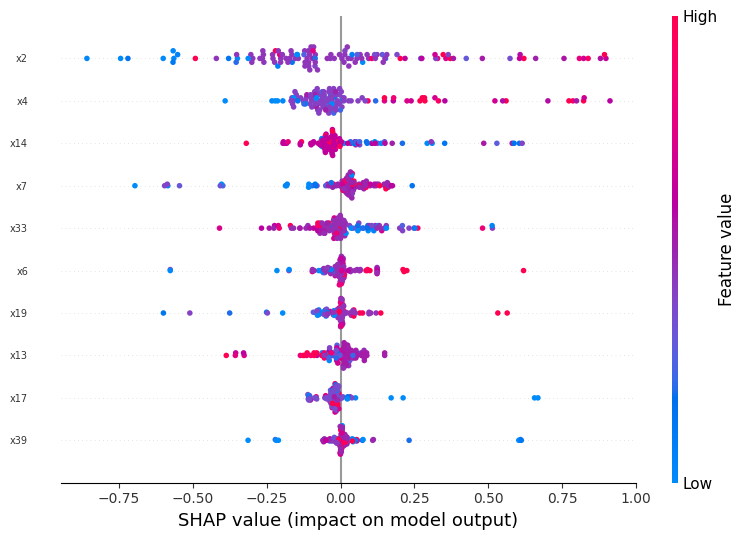

In [192]:
shap_values = model.predict(
    dtest,
    pred_contribs=True
)
plt.figure(figsize=(12, 16))
shap.summary_plot(
    shap_values[:, :-1],
    X_test,
    max_display=10,
    show=False
)

plt.yticks(fontsize=7)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

## 1000 round

In [165]:
boot_results = boot_multi_repeat_inference_keep_feature(
    X=X,
    y=y,
    task="binary",
    inner_variance="permutation",
    n_bootstrap=1000,
    b_model=1,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [01:10<00:00, 14.28it/s]


In [166]:
feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=boot_results,
    agg_col="sum_abs_shap",
    kernel="gaussian",
    bandwidth=0.1,
)

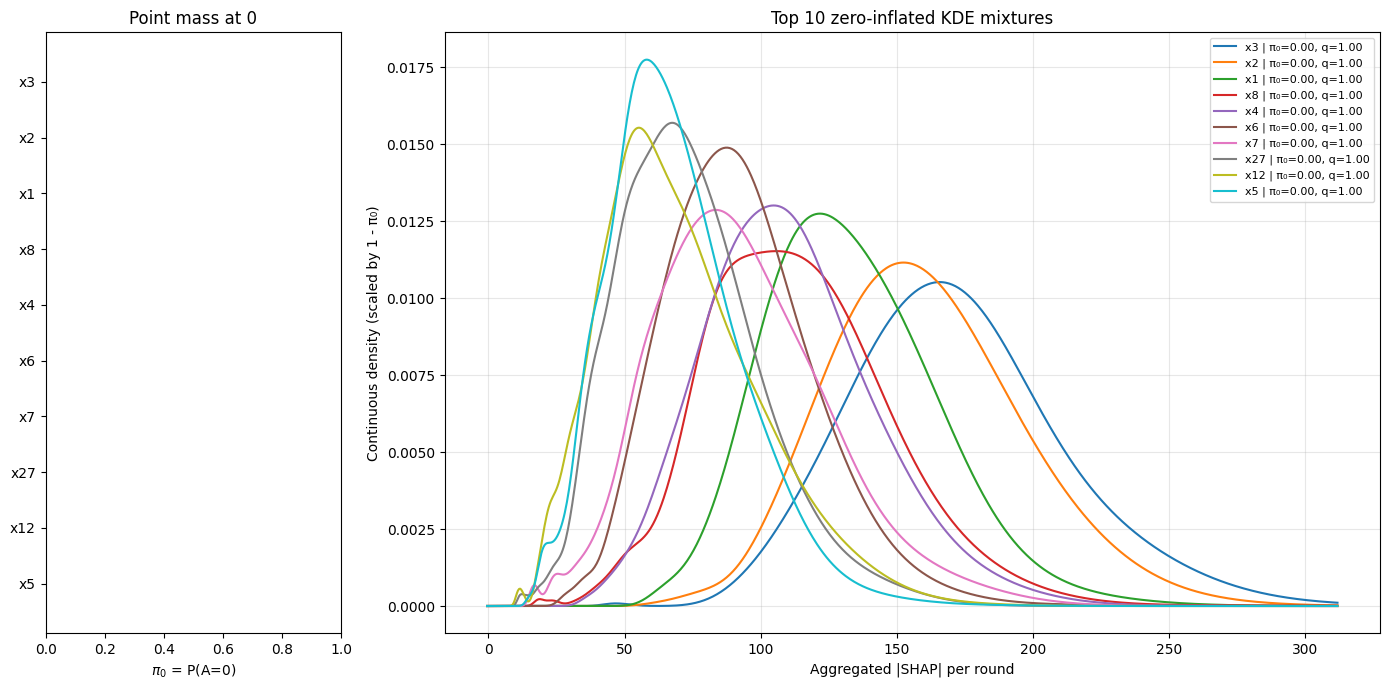

In [167]:
lgb_top = plot_top_feature_density(
    feature_kde,
    top_k=10,
    score_col="median",
    x_min = -0.5,
    log_x=False,
)

In [168]:
tmp = feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["median"] * tmp["SNR"]
                                
top = tmp.nlargest(10, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "ID",
    "stat": "Robust",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3)

,ID,Robust,SNR,Median,Std,0PM(%)
Rank,,,,,,
1,x3,721.234,4.237,170.231,40.179,0.0%
2,x2,680.159,4.291,158.511,36.941,0.0%
3,x1,532.249,4.077,130.543,32.018,0.0%
4,x4,376.615,3.443,109.373,31.763,0.0%
5,x8,369.815,3.293,112.292,34.097,0.0%
6,x6,298.216,3.276,91.029,27.786,0.0%
7,x7,250.952,2.787,90.043,32.308,0.0%
8,x27,193.864,2.710,71.528,26.391,0.0%
9,x5,177.530,2.686,66.100,24.611,0.0%


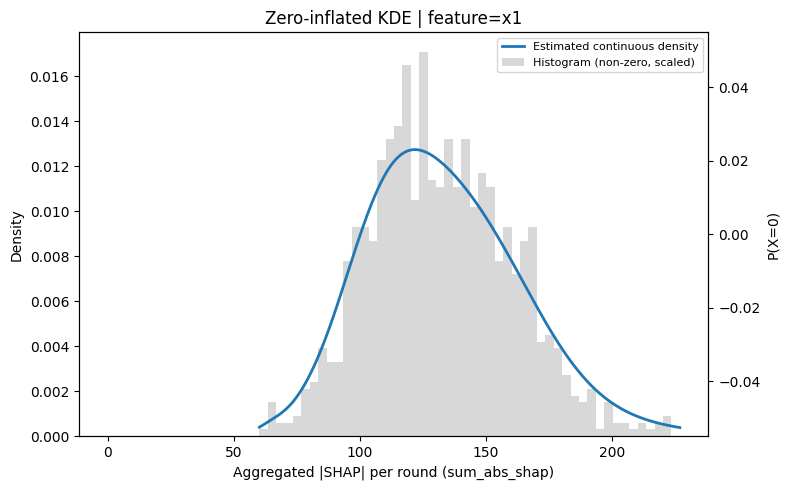

In [169]:
plot_feature_level_kde_with_hist_preagg(
    feature_level_df=feature_kde,
    boot_results=boot_results,
    feature="x1",
    bins = 50
)

In [170]:
from scipy.stats import shapiro

boot_df = pd.concat(boot_results, ignore_index=True)
x1_vals = boot_df.loc[boot_df["feature"] == "x1", "sum_abs_shap"].values

n = min(len(x1_vals), 5000)
stat, p = shapiro(x1_vals[:n])
print(f"Shapiro-Wilk normality test on x1 sum_abs_shap (n={n}):")
print(f"  W = {stat:.4f},  p = {p:.4e}")

Shapiro-Wilk normality test on x1 sum_abs_shap (n=1000):
  W = 0.9893,  p = 1.0725e-06


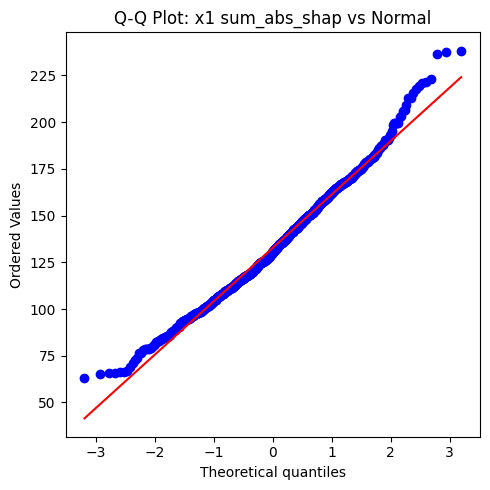

In [171]:
import scipy.stats as stats

fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(x1_vals, dist="norm", plot=ax)
ax.set_title("Q-Q Plot: x1 sum_abs_shap vs Normal")
plt.tight_layout()
plt.show()

## 10 round

In [172]:
boot_results_tiny = boot_multi_repeat_inference_keep_feature(
    X=X,
    y=y,
    task="binary",
    inner_variance="permutation",
    n_bootstrap=10,
    b_model=1,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 10/10 [00:00<00:00, 12.20it/s]


In [173]:
feature_kde_tiny = estimate_feature_level_mixture_preagg(
    boot_results=boot_results_tiny,
    agg_col="sum_abs_shap",
    kernel="gaussian",
    bandwidth=0.2,
)

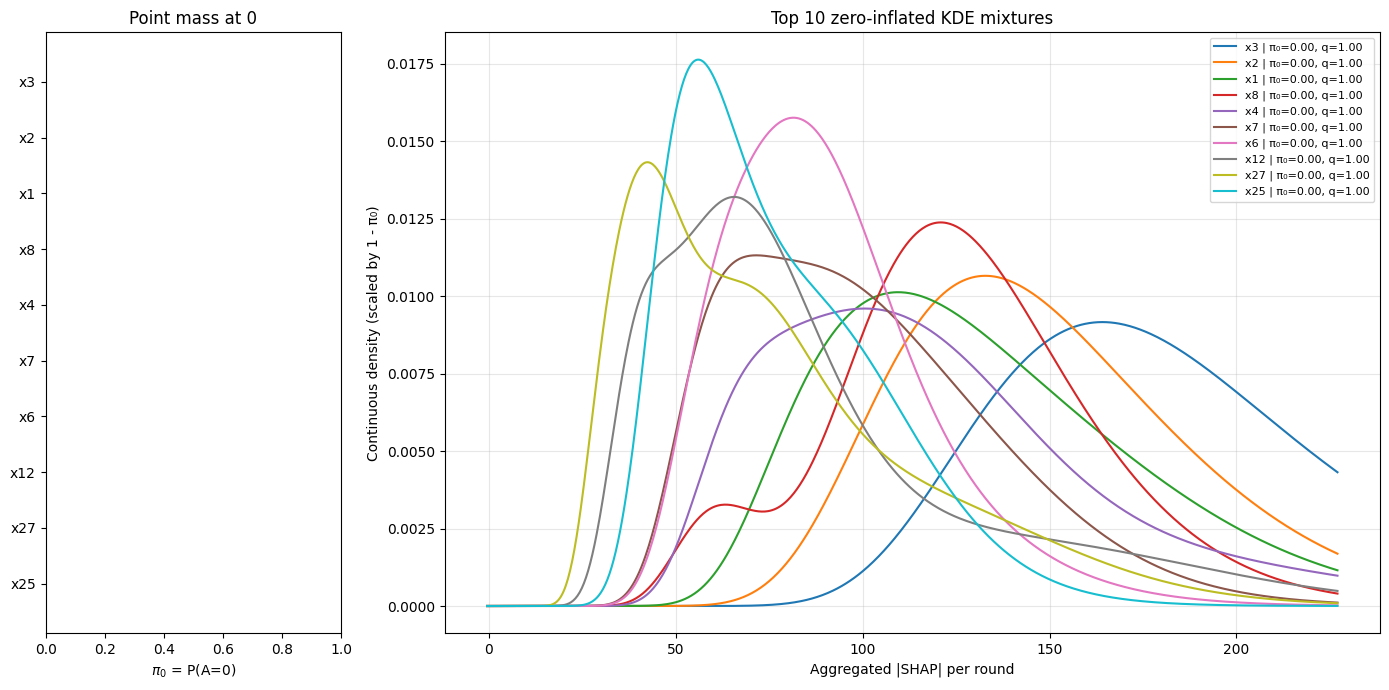

In [174]:
lgb_top = plot_top_feature_density(
    feature_kde_tiny,
    top_k=10,
    score_col="median",
    x_min = -0.5,
    log_x=False,
)

In [175]:
feature_kde_tiny.head()

,feature,n_bootstrap_rounds,n_total,n_zero,n_nonzero,pi_zero,bandwidth,kernel,zero_tol,kde_model,median,std,mean_abs_estimated,mean_estimated,var_estimated,sd_estimated,p_nonzero,peak_density,nonzero_median,nonzero_median_kde
0,x1,10,10,0,10,0.0,0.2,gaussian,0.0,"{'pi_zero': 0.0, 'n_total': 10, 'n_zero': 0, '...",122.922249,33.985439,112.213551,112.213551,2277.918870,47.727548,1.0,0.010123,122.922249,121.545113
1,x10,10,10,0,10,0.0,0.2,gaussian,0.0,"{'pi_zero': 0.0, 'n_total': 10, 'n_zero': 0, '...",43.947449,21.980774,41.480598,41.480598,457.093151,21.379737,1.0,0.026115,43.947451,41.318994
2,x11,10,10,0,10,0.0,0.2,gaussian,0.0,"{'pi_zero': 0.0, 'n_total': 10, 'n_zero': 0, '...",49.984421,23.265099,45.453432,45.453432,478.470129,21.873960,1.0,0.019883,49.984421,45.197189
3,x12,10,10,0,10,0.0,0.2,gaussian,0.0,"{'pi_zero': 0.0, 'n_total': 10, 'n_zero': 0, '...",72.149025,42.863037,75.589109,75.589109,1479.405781,38.463044,1.0,0.013196,72.149025,72.653921
4,x13,10,10,0,10,0.0,0.2,gaussian,0.0,"{'pi_zero': 0.0, 'n_total': 10, 'n_zero': 0, '...",62.940105,23.077213,50.748678,50.748678,702.211748,26.499278,1.0,0.013982,62.940105,56.935591


In [176]:
tmp = feature_kde_tiny.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["std"]
tmp["stat"] = tmp["p_nonzero"]* tmp["median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "ID",
    "stat": "Robust",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3)

,ID,Robust,SNR,Median,Std,0PM(%)
Rank,,,,,,
1,x3,1016.693,5.930,171.442,68.652,0.0%
2,x2,747.680,5.293,141.265,57.042,0.0%
3,x8,558.522,4.619,120.913,50.249,0.0%
4,x1,444.599,3.617,122.922,47.728,0.0%
5,x6,390.353,4.357,89.593,30.245,0.0%
6,x7,320.857,3.311,96.897,37.780,0.0%
7,x4,314.059,2.737,114.762,44.522,0.0%
8,x32,244.156,3.768,64.801,23.102,0.0%
9,x25,220.023,3.123,70.443,29.196,0.0%


## Prediction

In [201]:
sum_abs_shap = np.abs(shap_values[:,:-1]).sum(axis=0)
shap_top15 = (
    pd.Series(sum_abs_shap, index=X.columns)
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

In [202]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X[shap_top15], y, test_size=0.2, random_state=42, stratify=y)

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)
# Cross-validation on training data to find optimal parameters


num_rounds = 150 # number of iterations

In [203]:
# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    metrics='logloss',  # binary logloss
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "="*50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})")
print("="*50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")
model = xgb.train(params, dtrain, num_boost_round=best_num_rounds)

# Evaluate on held-out test set
# For binary:logistic, predict() returns probabilities, convert to class labels
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to 0/1

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["0", "1"]))

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.51760+0.00870	test-logloss:0.71427+0.02271
[1]	train-logloss:0.40138+0.01039	test-logloss:0.73201+0.02496
[2]	train-logloss:0.32289+0.01081	test-logloss:0.74194+0.01152
[3]	train-logloss:0.26490+0.01072	test-logloss:0.74552+0.01357
[4]	train-logloss:0.22621+0.01005	test-logloss:0.73224+0.01845
[5]	train-logloss:0.19405+0.00842	test-logloss:0.74413+0.02198
[6]	train-logloss:0.16593+0.00883	test-logloss:0.75340+0.01576
[7]	train-logloss:0.14556+0.00746	test-logloss:0.76121+0.01848
[8]	train-logloss:0.12991+0.00671	test-logloss:0.77015+0.03337
[9]	train-logloss:0.11559+0.00606	test-logloss:0.78252+0.03652
[10]	train-logloss:0.10399+0.00489	test-logloss:0.79717+0.03170

Cross-validation results:
Best iteration: 1
Best CV logloss: 0.7143 (+/- 0.0227)

Training final model with 1 rounds...

Test set accuracy: 0.5417

Confusion Matrix:
[[27 34]
 [21 38]]

Classification Report:
              precision    recall  f1-score 

In [204]:
top15 = top['feature'].head(10).tolist()

In [205]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X[top15], y, test_size=0.2, random_state=42, stratify=y)

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)
# Cross-validation on training data to find optimal parameters


num_rounds = 150 # number of iterations

In [206]:
# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    metrics='logloss',  # binary logloss
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "="*50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})")
print("="*50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")
model = xgb.train(params, dtrain, num_boost_round=best_num_rounds)

# Evaluate on held-out test set
# For binary:logistic, predict() returns probabilities, convert to class labels
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to 0/1

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["0", "1"]))

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.51385+0.00865	test-logloss:0.70715+0.02728
[1]	train-logloss:0.40579+0.00988	test-logloss:0.72165+0.03593
[2]	train-logloss:0.32348+0.00915	test-logloss:0.70742+0.02899
[3]	train-logloss:0.26793+0.00718	test-logloss:0.71520+0.04027
[4]	train-logloss:0.22522+0.00538	test-logloss:0.70981+0.04185
[5]	train-logloss:0.19261+0.00491	test-logloss:0.71519+0.04344
[6]	train-logloss:0.16425+0.00533	test-logloss:0.72889+0.05632
[7]	train-logloss:0.14384+0.00450	test-logloss:0.73425+0.06868
[8]	train-logloss:0.12764+0.00379	test-logloss:0.74676+0.07134
[9]	train-logloss:0.11416+0.00328	test-logloss:0.75779+0.07264
[10]	train-logloss:0.10276+0.00296	test-logloss:0.77364+0.06688

Cross-validation results:
Best iteration: 1
Best CV logloss: 0.7071 (+/- 0.0273)

Training final model with 1 rounds...

Test set accuracy: 0.6167

Confusion Matrix:
[[41 20]
 [26 33]]

Classification Report:
              precision    recall  f1-score 

# High dimension

In [8]:
df, truth = simulate_zero_inflated_classification(
    n=600,
    d=1000,
    s=10,
    sigma_signal=3,
    sigma_noise=1,
    pi_zero_signal=0.3,
    pi_zero_noise=0.2,
    max_delta=3,
    min_delta=0.8,
    seed=123
)

# df, truth = simulate_zero_inflated_classification(
#     n=600,
#     d=1000,
#     s=10,
#     sigma_signal=2.5,
#     sigma_noise=1,
#     pi_zero_signal=0.0,
#     pi_zero_noise=0.0,
#     max_delta=3,
#     min_delta=0.8,
#     seed=123
# )

# df, truth = simulate_zero_inflated_classification(
#     n=600,
#     d=400,
#     s=10,
#     sigma=3,
#     pi_zero=0.5,
#     max_delta=5,
#     min_delta=0.8,
#     seed=123
# )

# print(df.head())
print(truth.head(20))

   feature  is_signal     delta  sigma  pi_zero  true_rank
0       x1       True  3.000000      3      0.3        1.0
1       x2       True  2.755556      3      0.3        2.0
2       x3       True  2.511111      3      0.3        3.0
3       x4       True  2.266667      3      0.3        4.0
4       x5       True  2.022222      3      0.3        5.0
5       x6       True  1.777778      3      0.3        6.0
6       x7       True  1.533333      3      0.3        7.0
7       x8       True  1.288889      3      0.3        8.0
8       x9       True  1.044444      3      0.3        9.0
9      x10       True  0.800000      3      0.3       10.0
10     x11      False  0.000000      1      0.2        NaN
11     x12      False  0.000000      1      0.2        NaN
12     x13      False  0.000000      1      0.2        NaN
13     x14      False  0.000000      1      0.2        NaN
14     x15      False  0.000000      1      0.2        NaN
15     x16      False  0.000000      1      0.2        N

In [9]:
X = df.drop(columns="y")
y = df["y"]

In [10]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)
# Cross-validation on training data to find optimal parameters


num_rounds = 150 # number of iterations

In [15]:
# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    metrics='logloss',  # binary logloss
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "="*50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})")
print("="*50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")
model = xgb.train(params, dtrain, num_boost_round=best_num_rounds)

# Evaluate on held-out test set
# For binary:logistic, predict() returns probabilities, convert to class labels
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to 0/1

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["0", "1"]))

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.43239+0.00674	test-logloss:0.67812+0.01367
[1]	train-logloss:0.29773+0.00760	test-logloss:0.68229+0.04156
[2]	train-logloss:0.21786+0.00884	test-logloss:0.68803+0.02935
[3]	train-logloss:0.16152+0.00276	test-logloss:0.71762+0.03042
[4]	train-logloss:0.12543+0.00299	test-logloss:0.72821+0.06076
[5]	train-logloss:0.09795+0.00230	test-logloss:0.72426+0.05337
[6]	train-logloss:0.07783+0.00197	test-logloss:0.73930+0.05873
[7]	train-logloss:0.06241+0.00103	test-logloss:0.74257+0.06950
[8]	train-logloss:0.05121+0.00080	test-logloss:0.74689+0.08451
[9]	train-logloss:0.04315+0.00064	test-logloss:0.75113+0.09002
[10]	train-logloss:0.03678+0.00076	test-logloss:0.75321+0.09029

Cross-validation results:
Best iteration: 1
Best CV logloss: 0.6781 (+/- 0.0137)

Training final model with 1 rounds...

Test set accuracy: 0.6917

Confusion Matrix:
[[41 20]
 [17 42]]

Classification Report:
              precision    recall  f1-score 

/tmp/ipykernel_1014365/1029953288.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


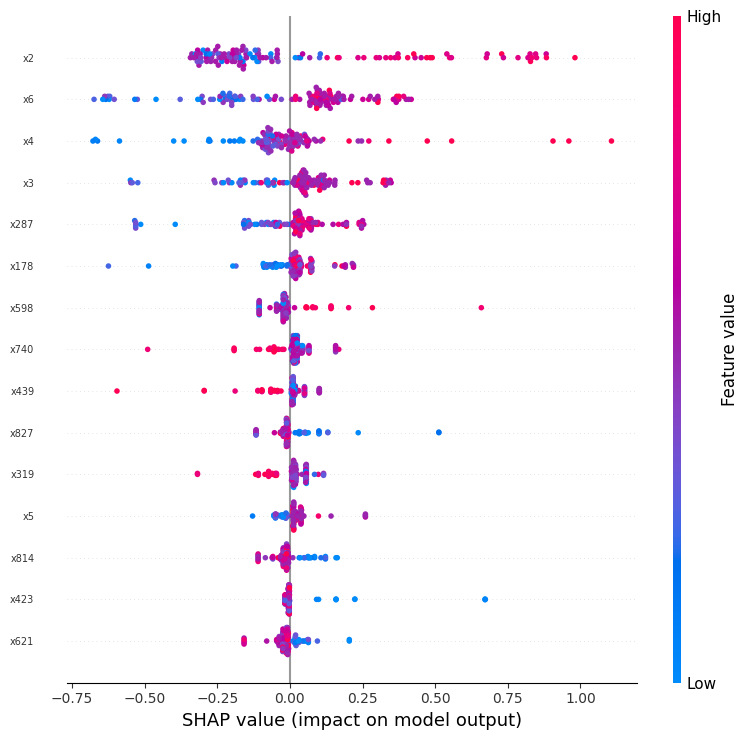

In [16]:
shap_values = model.predict(
    dtest,
    pred_contribs=True
)
plt.figure(figsize=(12, 16))
shap.summary_plot(
    shap_values[:, :-1],
    X_test,
    max_display=15,
    show=False
)

plt.yticks(fontsize=7)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

In [11]:
# 10 feautre's rank
abs_sum_shap = np.abs(shap_values[:, :-1]).sum(axis=0)

shap_rank_df = (
    pd.DataFrame({
        "feature": X_test.columns,   # or X.columns if you prefer full feature list
        "abs_sum_shap": abs_sum_shap
    })
    .sort_values("abs_sum_shap", ascending=False)
    .assign(rank=lambda d: d["abs_sum_shap"].rank(method="first", ascending=False).astype(int))
    .sort_values("rank")
)

true_vars = [f"x{i}" for i in range(1, 11)]
shap_rank_true = shap_rank_df[shap_rank_df["feature"].isin(true_vars)].sort_values("rank")

shap_rank_true

,feature,abs_sum_shap,rank
1,x2,35.239784,1
5,x6,25.857891,2
3,x4,15.377968,3
2,x3,15.143467,4
4,x5,4.124493,12
9,x10,0.136815,31
6,x7,0.000000,333
7,x8,0.000000,387
0,x1,0.000000,669
8,x9,0.000000,670


## 1000 round

In [11]:
boot_results = boot_multi_repeat_inference_keep_feature(
    X=X,
    y=y,
    task="binary",
    inner_variance="permutation",
    n_bootstrap=1000,
    b_model=1,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [10:37<00:00,  1.57it/s]


In [20]:
filepath = "shap_results/xgb_simulation.parquet"
pd.concat(boot_results, ignore_index=True).to_parquet(
    filepath,
    index=False,
    compression="zstd"
)
print("Saved!")

df_all = pd.read_parquet(filepath)
boot_results = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(boot_results)} bootstrap results")

Saved!
Loaded 1000 bootstrap results


In [13]:
feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=boot_results,
    agg_col="sum_abs_shap",
    kernel="gaussian",
    bandwidth=0.1,
)

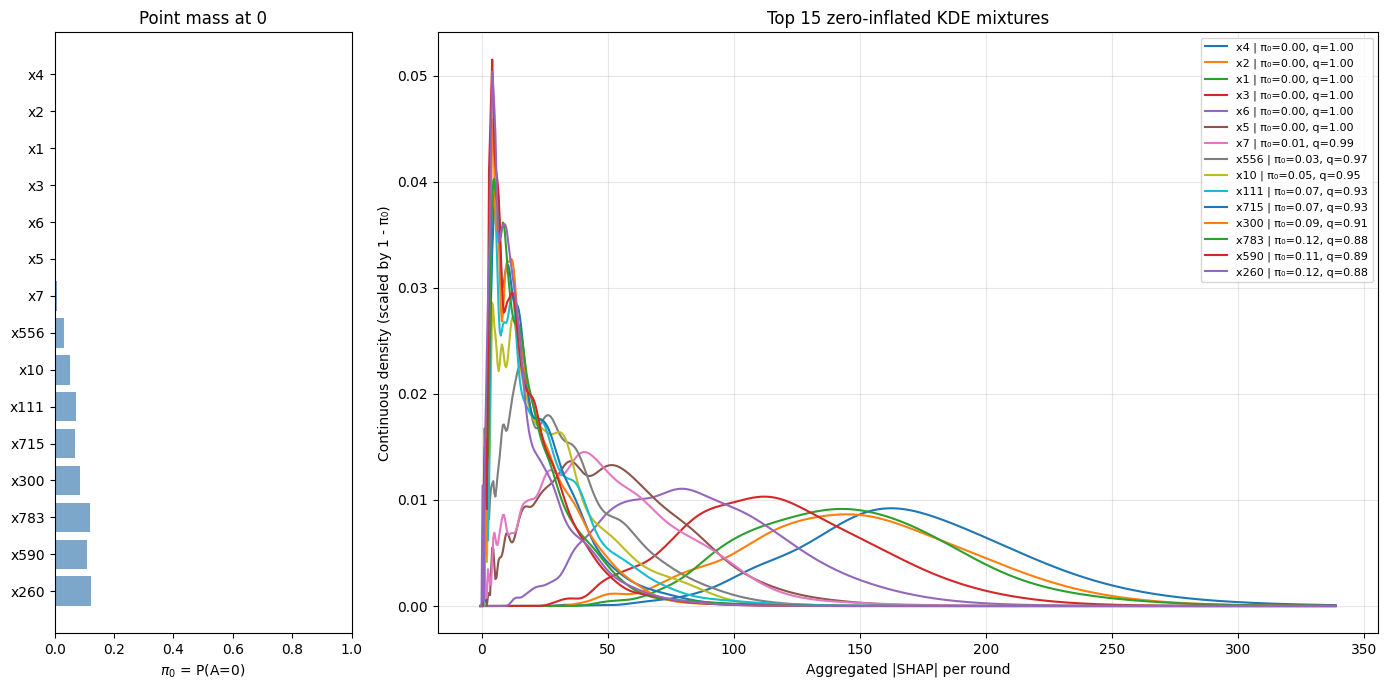

In [14]:
lgb_top = plot_top_feature_density(
    feature_kde,
    top_k=15,
    score_col="median",
    x_min = -0.5,
    log_x=False,
)

In [15]:
tmp = feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "ID",
    "stat": "Robust",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3)

,ID,Robust,SNR,Median,Std,0PM(%)
Rank,,,,,,
1,x4,610.666,3.613,169.006,46.774,0.0%
2,x1,494.602,3.394,145.735,42.941,0.0%
3,x2,479.921,3.215,149.258,46.420,0.0%
4,x3,345.201,2.960,116.620,39.398,0.0%
5,x6,196.960,2.339,84.222,36.014,0.0%
6,x5,91.887,1.774,51.983,29.264,0.2%
7,x7,75.236,1.581,48.084,30.325,0.8%
8,x556,33.853,1.208,29.580,23.934,3.0%
9,x10,21.743,1.024,24.108,21.874,5.2%


In [16]:
tmp = tmp.sort_values("stat", ascending=False)
tmp['rank'] = range(1, len(tmp) + 1)
tmp = tmp.loc[lambda df: df["feature"].isin(truth.loc[truth["is_signal"], "feature"])]

In [17]:
tmp[["rank", "feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "ID",
    "stat": "Robust",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3).head(10)

,rank,ID,Robust,SNR,Median,Std,0PM(%)
334,1,x4,610.666,3.613,169.006,46.774,0.0%
0,2,x1,494.602,3.394,145.735,42.941,0.0%
112,3,x2,479.921,3.215,149.258,46.420,0.0%
223,4,x3,345.201,2.960,116.620,39.398,0.0%
556,5,x6,196.960,2.339,84.222,36.014,0.0%
445,6,x5,91.887,1.774,51.983,29.264,0.2%
667,7,x7,75.236,1.581,48.084,30.325,0.8%
1,9,x10,21.743,1.024,24.108,21.874,5.2%
778,39,x8,2.233,0.473,9.443,13.088,23.9%
889,66,x9,1.317,0.474,7.174,8.773,33.2%


Fitted Gaussian for x1: mu=147.1821, sigma=40.0653


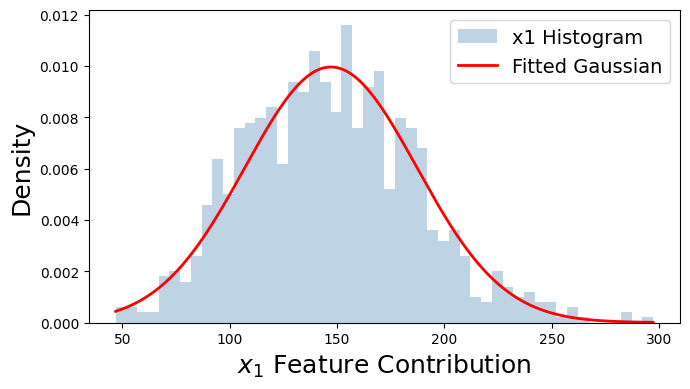

In [18]:
from scipy.stats import norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# collect x1 bootstrap SHAP values
boot_df = pd.concat(boot_results, ignore_index=True)
x1_vals = boot_df.loc[boot_df["feature"] == "x1", "sum_abs_shap"].dropna().values

# fit Normal(mu, sigma)
mu, sigma = norm.fit(x1_vals)
print(f"Fitted Gaussian for x1: mu={mu:.4f}, sigma={sigma:.4f}")

# plot histogram + fitted normal curve
plt.figure(figsize=(7, 4))
plt.hist(x1_vals, bins=50, density=True, alpha=0.35, color="steelblue", label="x1 Histogram")

x_grid = np.linspace(x1_vals.min(), x1_vals.max(), 400)
plt.plot(x_grid, norm.pdf(x_grid, loc=mu, scale=sigma), "r-", lw=2, label="Fitted Gaussian")

# plt.title("x1 sum_abs_shap with fitted Normal distribution")
plt.xlabel(r"$x_1$ Feature Contribution", fontsize=18)
plt.ylabel("Density", fontsize=18)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

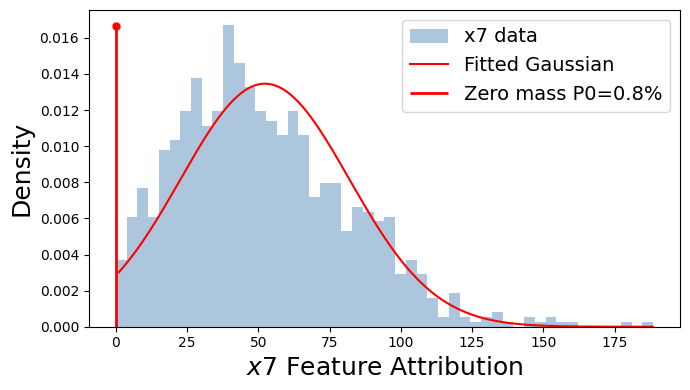

In [28]:
# ...existing code...
from scipy.stats import norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature = "x7"  # change to "x1" if needed

boot_df = pd.concat(boot_results, ignore_index=True)
vals = boot_df.loc[boot_df["feature"] == feature, "sum_abs_shap"].dropna().values

# split zero / nonzero
zero_mask = np.isclose(vals, 0.0000)
nonzero_vals = vals[~zero_mask]
p0 = zero_mask.mean()

fig, ax = plt.subplots(figsize=(7, 4))

# grey histogram for nonzero part only
if len(nonzero_vals) > 0:
    ax.hist(
        vals,
        bins=50,
        density=True,
        alpha=0.45,
        color="steelblue",
        edgecolor="none",
        label=f"{feature} data",
    )

    # fit Normal only on nonzero part
    mu, sigma = norm.fit(nonzero_vals)
    x_grid = np.linspace(nonzero_vals.min(), nonzero_vals.max(), 400)
    ax.plot(
        x_grid,
        norm.pdf(x_grid, loc=mu, scale=sigma),
        color="red",
        lw=1.5,
        label=f"Fitted Gaussian",
    )

# red spike for zero mass
if p0 > 0:  # only draw spike if there's actual zero mass
    spike_height = ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 1.0
    ax.vlines(0.0, 0.0, spike_height, colors="red", lw=2, label=f"Zero mass P0={p0*100:.1f}%")
    ax.scatter([0.0], [spike_height], color="red", s=25, zorder=5)

ax.set_xlabel(rf"${feature}$ Feature Attribution", fontsize=18)
ax.set_ylabel("Density", fontsize=18)
ax.legend(fontsize=14)
plt.tight_layout()
plt.show()
# ...existing code...

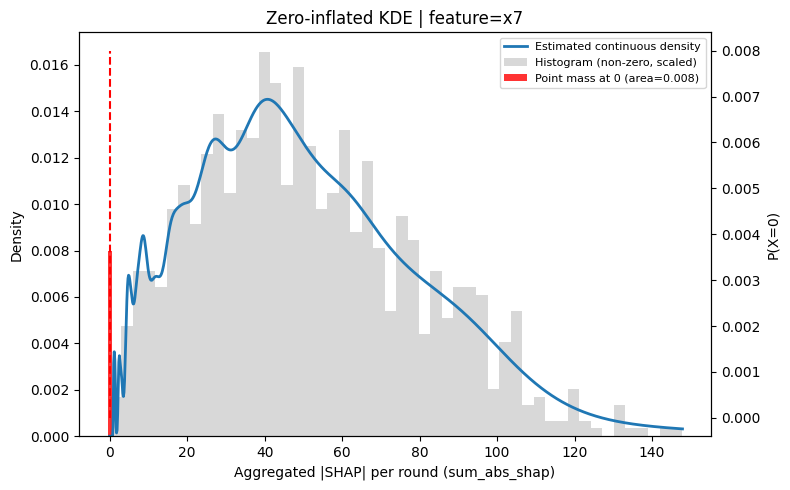

In [107]:
plot_feature_level_kde_with_hist_preagg(
    feature_level_df=feature_kde,
    boot_results=boot_results,
    feature="x7",
    bins = 50
)

In [54]:
from scipy.stats import shapiro

boot_df = pd.concat(boot_results, ignore_index=True)
x1_vals = boot_df.loc[boot_df["feature"] == "x1", "sum_abs_shap"].values

n = min(len(x1_vals), 5000)
stat, p = shapiro(x1_vals[:n])
print(f"Shapiro-Wilk normality test on x1 sum_abs_shap (n={n}):")
print(f"  W = {stat:.4f},  p = {p:.4e}")

Shapiro-Wilk normality test on x1 sum_abs_shap (n=1000):
  W = 0.9926,  p = 7.1296e-05


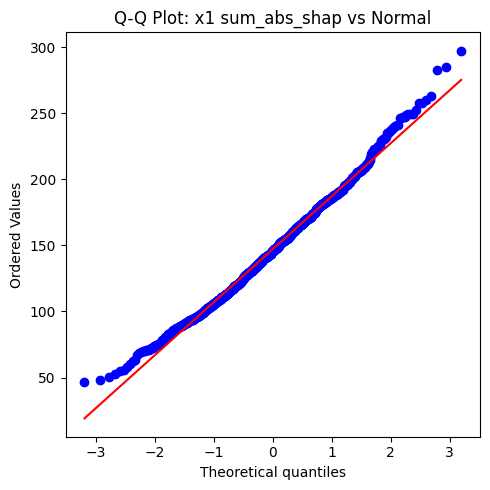

In [55]:
import scipy.stats as stats

fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(x1_vals, dist="norm", plot=ax)
ax.set_title("Q-Q Plot: x1 sum_abs_shap vs Normal")
plt.tight_layout()
plt.show()

## 10 round

In [108]:
boot_results_tiny = boot_multi_repeat_inference_keep_feature(
    X=X,
    y=y,
    task="binary",
    inner_variance="permutation",
    n_bootstrap=10,
    b_model=1,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 10/10 [00:11<00:00,  1.11s/it]


In [113]:
feature_kde_tiny = estimate_feature_level_mixture_preagg(
    boot_results=boot_results_tiny,
    agg_col="sum_abs_shap",
    kernel="gaussian",
    bandwidth=0.2,
)

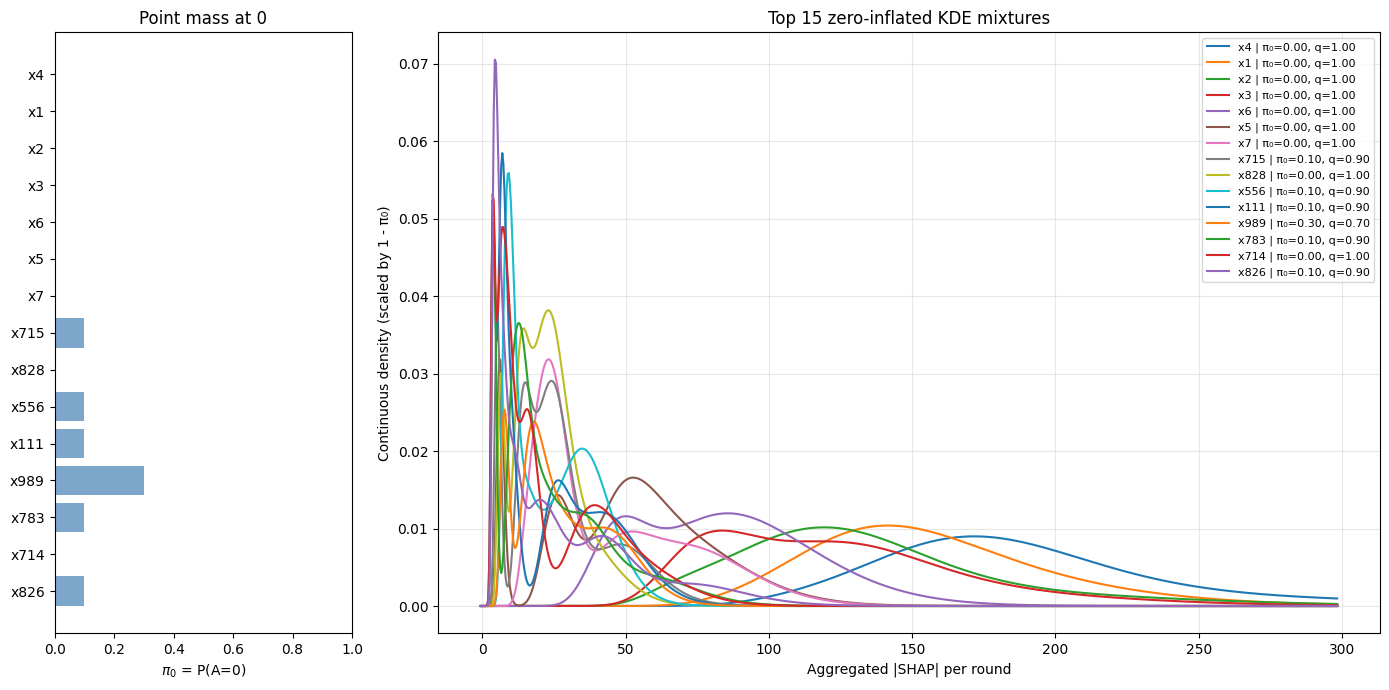

In [114]:
lgb_top = plot_top_feature_density(
    feature_kde_tiny,
    top_k=15,
    score_col="median",
    x_min = -0.5,
    log_x=False,
)

In [120]:
tmp = feature_kde_tiny.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["std"]
tmp["stat"] = tmp["p_nonzero"]* tmp["median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "ID",
    "stat": "Robust",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3)

,ID,Robust,SNR,Median,Std,0PM(%)
Rank,,,,,,
1,x4,779.543,4.246,183.587,59.426,0.0%
2,x1,767.569,5.141,149.299,53.683,0.0%
3,x2,433.423,3.255,133.140,46.813,0.0%
4,x3,430.414,3.331,129.220,44.783,0.0%
5,x6,271.179,3.230,83.950,33.523,0.0%
6,x5,104.682,2.026,51.658,25.451,0.0%
7,x7,60.939,1.536,39.663,23.255,0.0%
8,x828,52.680,2.228,23.649,10.337,0.0%
9,x715,29.612,1.388,24.717,14.630,10.0%


In [121]:
tmp = tmp.sort_values("stat", ascending=False)
tmp['rank'] = range(1, len(tmp) + 1)
tmp = tmp.loc[lambda df: df["feature"].isin(truth.loc[truth["is_signal"], "feature"])]
tmp[["rank", "feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "ID",
    "stat": "Robust",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3).head(10)

,rank,ID,Robust,SNR,Median,Std,0PM(%)
334,1,x4,779.543,4.246,183.587,59.426,0.0%
0,2,x1,767.569,5.141,149.299,53.683,0.0%
112,3,x2,433.423,3.255,133.140,46.813,0.0%
223,4,x3,430.414,3.331,129.220,44.783,0.0%
556,5,x6,271.179,3.230,83.950,33.523,0.0%
445,6,x5,104.682,2.026,51.658,25.451,0.0%
667,7,x7,60.939,1.536,39.663,23.255,0.0%
1,10,x10,25.849,1.744,14.819,7.821,0.0%
889,95,x9,2.641,0.593,8.850,8.601,30.0%
778,317,x8,0.317,0.208,5.547,7.939,40.0%


In [117]:
tmp = tmp.sort_values("stat", ascending=False)
tmp['rank'] = range(1, len(tmp) + 1)
tmp = tmp.loc[lambda df: df["feature"].isin(truth.loc[truth["is_signal"], "feature"])]

In [119]:
tmp[["rank", "feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "ID",
    "stat": "Robust",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3).head(10)

,rank,ID,Robust,SNR,Median,Std,0PM(%)
334,1,x4,779.543,4.246,183.587,59.426,0.0%
0,2,x1,767.569,5.141,149.299,53.683,0.0%
112,3,x2,433.423,3.255,133.140,46.813,0.0%
223,4,x3,430.414,3.331,129.220,44.783,0.0%
556,5,x6,271.179,3.230,83.950,33.523,0.0%
445,6,x5,104.682,2.026,51.658,25.451,0.0%
667,7,x7,60.939,1.536,39.663,23.255,0.0%
1,8,x10,25.849,1.744,14.819,7.821,0.0%
889,9,x9,2.641,0.593,8.850,8.601,30.0%
778,10,x8,0.317,0.208,5.547,7.939,40.0%


## Prediction

In [30]:
sum_abs_shap = np.abs(shap_values[:,:-1]).sum(axis=0)
shap_top15 = (
    pd.Series(sum_abs_shap, index=X.columns)
    .sort_values(ascending=False)
    .head(15)
    .index
    .tolist()
)

In [31]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X[shap_top15], y, test_size=0.2, random_state=42, stratify=y)

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)
# Cross-validation on training data to find optimal parameters


num_rounds = 150 # number of iterations

In [32]:
# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    metrics='logloss',  # binary logloss
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "="*50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})")
print("="*50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")
model = xgb.train(params, dtrain, num_boost_round=best_num_rounds)

# Evaluate on held-out test set
# For binary:logistic, predict() returns probabilities, convert to class labels
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to 0/1

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["0", "1"]))

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.47999+0.00614	test-logloss:0.67290+0.02622
[1]	train-logloss:0.36531+0.00790	test-logloss:0.67567+0.04154
[2]	train-logloss:0.28403+0.01223	test-logloss:0.64870+0.05694
[3]	train-logloss:0.22460+0.00831	test-logloss:0.63739+0.05404
[4]	train-logloss:0.18258+0.00813	test-logloss:0.65205+0.05976
[5]	train-logloss:0.15090+0.00627	test-logloss:0.64259+0.06456
[6]	train-logloss:0.12609+0.00564	test-logloss:0.64070+0.07423
[7]	train-logloss:0.10752+0.00361	test-logloss:0.63952+0.07061
[8]	train-logloss:0.09514+0.00313	test-logloss:0.64721+0.07114
[9]	train-logloss:0.08417+0.00253	test-logloss:0.64065+0.06974
[10]	train-logloss:0.07489+0.00129	test-logloss:0.64041+0.07297
[11]	train-logloss:0.06668+0.00115	test-logloss:0.64440+0.07225
[12]	train-logloss:0.05999+0.00080	test-logloss:0.64689+0.08634
[13]	train-logloss:0.05433+0.00068	test-logloss:0.64348+0.08578

Cross-validation results:
Best iteration: 4
Best CV logloss: 

In [33]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X[top15], y, test_size=0.2, random_state=42, stratify=y)

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)
# Cross-validation on training data to find optimal parameters


num_rounds = 150 # number of iterations

NameError: name 'top15' is not defined

In [23]:
# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    metrics='logloss',  # binary logloss
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "="*50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})")
print("="*50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")
model = xgb.train(params, dtrain, num_boost_round=best_num_rounds)

# Evaluate on held-out test set
# For binary:logistic, predict() returns probabilities, convert to class labels
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to 0/1

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["0", "1"]))

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.47999+0.00614	test-logloss:0.67290+0.02622


[1]	train-logloss:0.36531+0.00790	test-logloss:0.67567+0.04154
[2]	train-logloss:0.28403+0.01223	test-logloss:0.64870+0.05694
[3]	train-logloss:0.22460+0.00831	test-logloss:0.63739+0.05404
[4]	train-logloss:0.18258+0.00813	test-logloss:0.65205+0.05976
[5]	train-logloss:0.15090+0.00627	test-logloss:0.64259+0.06456
[6]	train-logloss:0.12609+0.00564	test-logloss:0.64070+0.07423
[7]	train-logloss:0.10752+0.00361	test-logloss:0.63952+0.07061
[8]	train-logloss:0.09514+0.00313	test-logloss:0.64721+0.07114
[9]	train-logloss:0.08417+0.00253	test-logloss:0.64065+0.06974
[10]	train-logloss:0.07489+0.00129	test-logloss:0.64041+0.07297
[11]	train-logloss:0.06668+0.00115	test-logloss:0.64440+0.07225
[12]	train-logloss:0.05999+0.00080	test-logloss:0.64689+0.08634
[13]	train-logloss:0.05433+0.00068	test-logloss:0.64348+0.08578

Cross-validation results:
Best iteration: 4
Best CV logloss: 0.6374 (+/- 0.0540)

Training final model with 4 rounds...

Test set accuracy: 0.6583

Confusion Matrix:
[[44 17]
 

In [51]:
print('Computing Information Gain scores...')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ig_scores = mutual_info_regression(X_train, y_train, random_state=42)

signal_features = set(truth.loc[truth['is_signal'], 'feature'])

ig_ranking = (
    pd.DataFrame({'feature': X_train.columns, 'importance': ig_scores})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
ig_ranking['rank'] = ig_ranking.index + 1

signal_ig_table = (
    ig_ranking[ig_ranking['feature'].isin(signal_features)]
    [['rank', 'feature', 'importance']]
    .rename(columns={'feature': 'id', 'importance': 'score'})
    .sort_values('rank')
)

print(signal_ig_table.head(10).to_string(index=False))

Computing Information Gain scores...
 rank  id    score
    1  x4 0.090337
   48  x2 0.043017
  187  x5 0.024448
  235  x6 0.020645
  259  x1 0.018597
  281  x3 0.016729
  292  x7 0.015321
  329  x9 0.011755
  658 x10 0.000000
  744  x8 0.000000


In [49]:
print('Computing Gain ranking for XGBoost...')
xgboost_gain = get_gain_ranking(MODELS['XGBoost'], X_train, y_train)

signal_features = set(truth.loc[truth['is_signal'], 'feature'])

xgboost_gain_ranked = (
    xgboost_gain
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
xgboost_gain_ranked['rank'] = xgboost_gain_ranked.index + 1

signal_gain_table = (
    xgboost_gain_ranked[xgboost_gain_ranked['feature'].isin(signal_features)]
    [['rank', 'feature', 'importance']]
    .rename(columns={'feature': 'id', 'importance': 'score'})
    .sort_values('rank')
)

print(signal_gain_table.head(10).to_string(index=False))

Computing Gain ranking for XGBoost...
 rank  id    score
    5  x1 1.826468
    6  x2 1.781809
   10  x3 1.695945
   13  x4 1.449856
   26  x6 1.069029
   41  x7 0.886768
   74 x10 0.686088
  131  x5 0.554561
  159  x8 0.493847
  707  x9 0.063074


In [56]:
print('Computing LIME ranking for XGBoost...')
xgboost_lime = get_lime_ranking(
    MODELS['XGBoost'], X_train, y_train,
    n_samples=5,    # increase for better estimates
    num_features=10, # top features per explanation
)

signal_features = set(truth.loc[truth['is_signal'], 'feature'])

xgboost_lime_ranked = (
    xgboost_lime
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
 )
xgboost_lime_ranked['rank'] = xgboost_lime_ranked.index + 1

signal_lime_table = (
    xgboost_lime_ranked[xgboost_lime_ranked['feature'].isin(signal_features)]
    [['rank', 'feature', 'importance']]
    .rename(columns={'feature': 'id', 'importance': 'score'})
    .sort_values('rank')
 )

print(signal_lime_table.head(10).to_string(index=False))

Computing LIME ranking for XGBoost...
 rank  id    score
    1  x3 0.076770
    2  x1 0.075179
    3  x2 0.054622
    4  x4 0.035989
    5  x6 0.035015
    7  x7 0.007913
   15 x10 0.004280
   58  x9 0.000000
  960  x8 0.000000
  999  x5 0.000000


In [55]:
print('Computing LIME ranking for XGBoost...')
xgboost_lime = get_lime_ranking(
    MODELS['XGBoost'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)

signal_features = set(truth.loc[truth['is_signal'], 'feature'])

xgboost_lime_ranked = (
    xgboost_lime
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
 )
xgboost_lime_ranked['rank'] = xgboost_lime_ranked.index + 1

signal_lime_table = (
    xgboost_lime_ranked[xgboost_lime_ranked['feature'].isin(signal_features)]
    [['rank', 'feature', 'importance']]
    .rename(columns={'feature': 'id', 'importance': 'score'})
    .sort_values('rank')
 )

print(signal_lime_table.head(10).to_string(index=False))

Computing LIME ranking for XGBoost...
 rank  id    score
    1  x2 0.061498
    2  x1 0.057046
    3  x3 0.050713
    4  x4 0.048248
    5  x6 0.035837
    7  x7 0.011787
   10 x10 0.009498
   12  x5 0.008658
  341  x9 0.000000
  985  x8 0.000000
